<a href="https://colab.research.google.com/github/LesTa98/northstar-data-analysis/blob/main/northstar-data-analysis/notebooks/01_python_pandas_numpy_cleaning_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
sns.set()

In [91]:
deliveries = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/deliveries.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/orders.csv")
customers = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/customers.csv")
drivers = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/drivers.csv")
vehicles = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/vehicles.csv")
hubs = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/hubs.csv")
complaints = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/complaints.csv")
incidents = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/incidents.csv")
app_events = pd.read_csv("https://raw.githubusercontent.com/LesTa98/northstar-data-analysis/refs/heads/main/data/raw/app_events.csv")

The code below loops through all datasets and checks their size, missing values, and duplicate rows to understand the data quality before cleaning it.

In [92]:
datasets = {
    "deliveries": deliveries,
    "orders": orders,
    "customers": customers,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "complaints": complaints,
    "incidents": incidents,
    "app_events": app_events
}

for name, df in datasets.items():
  print("DATASET:", name)
  print("SHAPE:", df.shape)
  print("NULLS: \n", df.isnull().sum())
  print("DUPLICATES:", df.duplicated().sum())
  print("-------------\n")

DATASET: deliveries
SHAPE: (950, 13)
NULLS: 
 delivery_id                       0
order_id                          0
driver_id                         0
vehicle_id                        0
hub_id                            0
dispatch_time                     0
delivery_completed_at            19
delivery_status                   0
route_distance_km                 0
manual_route_override_count       0
proof_of_completion_missing       0
customer_rating_post_delivery    14
fuel_or_charge_cost               0
dtype: int64
DUPLICATES: 0
-------------

DATASET: orders
SHAPE: (1250, 11)
NULLS: 
 order_id                  0
customer_id               0
service_type              0
order_created_at          0
promised_window_hours     0
pickup_zone               0
dropoff_zone              0
priority_level            0
order_value               0
booking_channel          25
special_handling_flag     0
dtype: int64
DUPLICATES: 0
-------------

DATASET: customers
SHAPE: (650, 9)
NULLS: 
 custome

The code below standardises the column names across all datasets

In [93]:
def clean_cols(df):
  df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")
  return df

for key in datasets:
  datasets[key] = clean_cols(datasets[key])

deliveries = datasets["deliveries"]
orders = datasets["orders"]
customers = datasets["customers"]
drivers = datasets["drivers"]
vehicles = datasets["vehicles"]
hubs = datasets["hubs"]
complaints = datasets["complaints"]
incidents = datasets["incidents"]
app_events = datasets["app_events"]

The code below fixes the data types in the tables for analysis.

Deliveries Table:


In [94]:
#datetime columns
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"], errors="coerce").dt.floor("s")
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"], errors="coerce").dt.floor("s")

#numeric columns
deliveries["route_distance_km"] = pd.to_numeric(deliveries["route_distance_km"], errors="coerce").round(2)
deliveries["manual_route_override_count"] = pd.to_numeric(deliveries["manual_route_override_count"], errors="coerce")
deliveries["proof_of_completion_missing"] = pd.to_numeric(deliveries["proof_of_completion_missing"], errors="coerce")
deliveries["customer_rating_post_delivery"] = pd.to_numeric(deliveries["customer_rating_post_delivery"], errors="coerce").round(2)
deliveries["fuel_or_charge_cost"] = pd.to_numeric(deliveries["fuel_or_charge_cost"], errors="coerce").round(2)

#convert delivery_status to category
deliveries["delivery_status"] = deliveries["delivery_status"].astype("category")

deliveries.info()
deliveries.head()





<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   delivery_id                    950 non-null    object        
 1   order_id                       950 non-null    object        
 2   driver_id                      950 non-null    object        
 3   vehicle_id                     950 non-null    object        
 4   hub_id                         950 non-null    object        
 5   dispatch_time                  950 non-null    datetime64[ns]
 6   delivery_completed_at          931 non-null    datetime64[ns]
 7   delivery_status                950 non-null    category      
 8   route_distance_km              950 non-null    float64       
 9   manual_route_override_count    950 non-null    int64         
 10  proof_of_completion_missing    950 non-null    int64         
 11  customer_rating_pos

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22


Orders Table:


In [95]:
# datetime column
orders["order_created_at"] = pd.to_datetime(orders['order_created_at'], errors="coerce").dt.floor("s")

# numeric columns
orders["promised_window_hours"] = pd.to_numeric(orders["promised_window_hours"], errors="coerce")
orders["order_vlaue"] = pd.to_numeric(orders["order_value"],errors="coerce").round(2)
orders["special_handling_flag"] = pd.to_numeric(orders["special_handling_flag"], errors="coerce")

# categorical columns
categorical_cols = ["service_type", "pickup_zone", "dropoff_zone", "priority_level", "booking_channel"]
for col in categorical_cols:
   orders[col] = orders[col].astype("category")

orders.info()
orders.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   order_id               1250 non-null   object        
 1   customer_id            1250 non-null   object        
 2   service_type           1250 non-null   category      
 3   order_created_at       1250 non-null   datetime64[ns]
 4   promised_window_hours  1250 non-null   int64         
 5   pickup_zone            1250 non-null   category      
 6   dropoff_zone           1250 non-null   category      
 7   priority_level         1250 non-null   category      
 8   order_value            1250 non-null   float64       
 9   booking_channel        1225 non-null   category      
 10  special_handling_flag  1250 non-null   int64         
 11  order_vlaue            1250 non-null   float64       
dtypes: category(5), datetime64[ns](1), float64(2), int64(2), objec

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag,order_vlaue
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0,126.65
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0,109.30
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0,33.50
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1,10.04
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0,125.58


Customers Table:

In [96]:
# datetime column
customers["signup_date"] = pd.to_datetime(customers["signup_date"], errors="coerce").dt.floor("s")

# numeric columns
customers["age"] = pd.to_numeric(customers["age"], errors="coerce")
customers["loyalty_score"] = pd.to_numeric(customers["loyalty_score"], errors="coerce").round(2)
customers["app_engagement_score"] = pd.to_numeric(customers["app_engagement_score"], errors="coerce").round(2)

# categorical columns
categorical_cols = ["home_zone", "customer_type", "preferred_channel", "account_status"]
for col in categorical_cols:
    customers[col] = customers[col].astype("category")

customers.info()
customers.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   customer_id           650 non-null    object        
 1   age                   650 non-null    int64         
 2   home_zone             650 non-null    category      
 3   customer_type         650 non-null    category      
 4   signup_date           650 non-null    datetime64[ns]
 5   loyalty_score         630 non-null    float64       
 6   app_engagement_score  650 non-null    float64       
 7   preferred_channel     637 non-null    category      
 8   account_status        650 non-null    category      
dtypes: category(4), datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 29.2+ KB


,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


Drivers Table:

In [97]:
# numeric columns
drivers["years_experience"] = pd.to_numeric(drivers["years_experience"], errors="coerce")
drivers["training_score"] = pd.to_numeric(drivers["training_score"], errors="coerce").round(2)
drivers["driver_rating"] = pd.to_numeric(drivers["driver_rating"], errors="coerce").round(2)
drivers["active_flag"] = pd.to_numeric(drivers["active_flag"], errors="coerce").astype("int")

# categorical columns
categorical_cols = ["base_zone", "employment_type", "shift_preference"]
for col in categorical_cols:
    drivers[col] = drivers[col].astype("category")

drivers.info()
drivers.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   driver_id         170 non-null    object  
 1   base_zone         170 non-null    category
 2   employment_type   170 non-null    category
 3   years_experience  170 non-null    int64   
 4   training_score    163 non-null    float64 
 5   driver_rating     170 non-null    float64 
 6   shift_preference  170 non-null    category
 7   active_flag       170 non-null    int64   
dtypes: category(3), float64(2), int64(2), object(1)
memory usage: 8.3+ KB


,driver_id,base_zone,employment_type,years_experience,training_score,driver_rating,shift_preference,active_flag
0,D001,AIRPORT,FullTime,8,67.8,3.54,Morning,1
1,D002,Central,FullTime,4,42.4,3.94,Evening,1
2,D003,AIRPORT,FullTime,11,96.5,5.00,Evening,1
3,D004,Airport,PartTime,13,88.9,4.75,Morning,1
4,D005,north,FullTime,3,69.7,4.14,Morning,1


Vehicles Table:


In [98]:
# datetime column
vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"], errors="coerce").dt.floor("s")

# numeric columns
vehicles["battery_health_pct"] = pd.to_numeric(vehicles["battery_health_pct"], errors="coerce").round(2)
vehicles["odometer_km"] = pd.to_numeric(vehicles["odometer_km"], errors="coerce")

# categorical columns
categorical_cols = ["vehicle_type", "assigned_zone", "maintenance_status", "telematics_version"]
for col in categorical_cols:
    vehicles[col] = vehicles[col].astype("category")

vehicles.info()
vehicles.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   vehicle_id          120 non-null    object        
 1   vehicle_type        120 non-null    category      
 2   assigned_zone       120 non-null    category      
 3   commission_date     120 non-null    datetime64[ns]
 4   battery_health_pct  116 non-null    float64       
 5   odometer_km         120 non-null    int64         
 6   maintenance_status  120 non-null    category      
 7   telematics_version  120 non-null    category      
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 5.5+ KB


,vehicle_id,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
0,V001,EV,North,2024-12-28 23:48:00,71.8,56928,Active,v2.2
1,V002,EV,AIRPORT,2024-04-21 16:14:00,67.9,159368,InRepair,v2.2
2,V003,CargoVan,north,2025-11-24 23:59:00,91.7,219359,Active,v2.1
3,V004,Hybrid,RiverSide,2024-06-07 13:21:00,NaN,36310,Active,v2.2
4,V005,CargoVan,West,2025-11-15 11:08:00,58.6,146638,Active,v2.2


Hubs Table:

In [99]:
# numeric columns
hubs["capacity_score"] = pd.to_numeric(hubs["capacity_score"], errors="coerce").round(2)

# categorical columns
categorical_cols = [ "zone", "hub_type"]
for col in categorical_cols:
  hubs[col] = hubs[col].astype("category")

hubs.info()
hubs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   hub_id          8 non-null      object  
 1   hub_name        8 non-null      object  
 2   zone            8 non-null      category
 3   hub_type        8 non-null      category
 4   capacity_score  8 non-null      int64   
dtypes: category(2), int64(1), object(2)
memory usage: 900.0+ bytes


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74
3,H04,West Gate,West,Dispatch,69
4,H05,Central Core,Central,Control,88


Complaints Table:


In [100]:
# datetime column
complaints["created_at"] = pd.to_datetime(complaints["created_at"], errors="coerce").dt.floor("s")

#numerical columns
complaints["resolution_days"] = pd.to_numeric(complaints["resolution_days"],errors="coerce")
complaints["compensation_amount"] = pd.to_numeric(complaints["compensation_amount"], errors="coerce").round(2)

#catergorical columms
categorical_cols = ["complaint_type", "channel", "severity", "status"]
for col in categorical_cols:
  complaints[col] = complaints[col].astype("category")

complaints.info()
complaints.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   complaint_id         320 non-null    object        
 1   customer_id          320 non-null    object        
 2   order_id             320 non-null    object        
 3   complaint_type       320 non-null    category      
 4   channel              320 non-null    category      
 5   severity             320 non-null    category      
 6   created_at           320 non-null    datetime64[ns]
 7   status               320 non-null    category      
 8   resolution_days      320 non-null    int64         
 9   compensation_amount  304 non-null    float64       
dtypes: category(4), datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 17.3+ KB


,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


Incidents Table:

In [101]:
#datetime column
incidents["reported_at"] = pd.to_datetime(incidents["reported_at"], errors="coerce").dt.floor("s")

#numerical column
incidents["resolved_hours"] = pd.to_numeric(incidents["resolved_hours"], errors="coerce")

#catergorical columms
categorical_cols = ["incident_type", "severity", "resolution_status"]
for col in categorical_cols:
  incidents[col] = incidents[col].astype("category")

incidents.info()
incidents.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   incident_id        280 non-null    object        
 1   delivery_id        280 non-null    object        
 2   incident_type      280 non-null    category      
 3   reported_at        280 non-null    datetime64[ns]
 4   severity           280 non-null    category      
 5   resolution_status  280 non-null    category      
 6   resolved_hours     263 non-null    float64       
dtypes: category(3), datetime64[ns](1), float64(1), object(2)
memory usage: 10.5+ KB


,incident_id,delivery_id,incident_type,reported_at,severity,resolution_status,resolved_hours
0,I0001,DL00221,BatteryAlert,2024-03-11 23:46:00,Medium,Escalated,12.3
1,I0002,DL00578,BatteryAlert,2024-02-21 10:56:00,Low,Open,9.6
2,I0003,DL00175,TemperatureIssue,2025-04-17 23:22:00,Medium,Open,22.0
3,I0004,DL00417,ProofMissing,2025-02-09 00:16:00,Medium,Closed,9.8
4,I0005,DL00897,RouteDeviation,2025-01-04 02:49:00,Low,Open,13.0


App Events Table:


In [102]:
#datetime column
app_events["event_timestamp"] = pd.to_datetime(app_events["event_timestamp"], errors="coerce").dt.floor("s")

#numerical column
app_events["api_latency_ms"] = pd.to_numeric(app_events["api_latency_ms"], errors="coerce")
app_events["success_flag"] = pd.to_numeric(app_events["success_flag"],errors="coerce")

#catergorical columms
categorical_cols = ["event_type", "device_type", "zone_context"]
for col in categorical_cols:
    app_events[col] = app_events[col].astype("category")

app_events.info()
app_events.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 640 entries, 0 to 639
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   event_id         640 non-null    object        
 1   customer_id      640 non-null    object        
 2   order_id         496 non-null    object        
 3   event_timestamp  640 non-null    datetime64[ns]
 4   event_type       640 non-null    category      
 5   session_id       640 non-null    object        
 6   device_type      640 non-null    category      
 7   zone_context     640 non-null    category      
 8   api_latency_ms   640 non-null    int64         
 9   success_flag     640 non-null    int64         
dtypes: category(3), datetime64[ns](1), int64(2), object(4)
memory usage: 38.2+ KB


,event_id,customer_id,order_id,event_timestamp,event_type,session_id,device_type,zone_context,api_latency_ms,success_flag
0,AE00001,C0488,NaN,2024-08-09 03:25:00,eta_refresh,S19847,Android,north,301,1
1,AE00002,C0595,O00950,2024-02-13 22:29:00,search_route,S32766,Android,SOUTH,60,1
2,AE00003,C0494,O00170,2025-08-11 09:29:00,chat_opened,S99516,iOS,Airport,1118,1
3,AE00004,C0407,O00756,2025-08-23 17:38:00,eta_refresh,S41236,iOS,CENTRAL,442,1
4,AE00005,C0506,NaN,2024-05-29 10:33:00,search_route,S12030,iOS,north,60,1


The code below fixes the missing values in the tables.

In [103]:
def handle_missing(df, numeric_fill="median", categorical_fill="Unknown"):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            # Numeric
            if pd.api.types.is_numeric_dtype(df[col]):
                if numeric_fill == "median":
                    df[col] = df[col].fillna(df[col].median())
                else:
                    df[col] = df[col].fillna(numeric_fill)

            # Categorical / object
            elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
                if pd.api.types.is_categorical_dtype(df[col]):
                    if categorical_fill not in df[col].cat.categories:
                        df[col] = df[col].cat.add_categories(categorical_fill)
                df[col] = df[col].fillna(categorical_fill)

            # Datetime
            elif pd.api.types.is_datetime64_any_dtype(df[col]):
                df[col] = df[col].fillna(df[col].min())
    return df


for name, df in datasets.items():
  datasets[name] = handle_missing(df)

# the "False" output from the function below proves all the missing values have handled
for name, df in datasets.items():
  print(f"{name} has NaNs? {df.isnull().values.any()}")

deliveries has NaNs? False
orders has NaNs? False
customers has NaNs? False
drivers has NaNs? False
vehicles has NaNs? False
hubs has NaNs? False
complaints has NaNs? False
incidents has NaNs? False
app_events has NaNs? False


/tmp/ipykernel_5519/3989886929.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(df[col]) or pd.api.types.is_object_dtype(df[col]):
/tmp/ipykernel_5519/3989886929.py:13: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(df[col]):


The code below removes invalid values in the tables

In [104]:
def fix_invalid_values(all_tables):
    for name, df in all_tables.items():

        # numeric fix
        for col in df.select_dtypes(include=["number"]).columns:
            if (df[col] < 0).any():
                median_val = df[col][df[col] >= 0].median()
                df[col] = df[col].mask(df[col] < 0, median_val)

        # Table specific fixes

        if name == "deliveries":
            # Ratings 0-5
            if "customer_rating_post_delivery" in df.columns:
                df["customer_rating_post_delivery"] = df["customer_rating_post_delivery"].clip(0, 5)
            # Ensure delivery_completed_at >= dispatch_time
            if "delivery_completed_at" in df.columns and "dispatch_time" in df.columns:
                invalid_mask = df["delivery_completed_at"] < df["dispatch_time"]
                df.loc[invalid_mask, "delivery_completed_at"] = df.loc[invalid_mask, "dispatch_time"]

        if name == "orders":
            if "promised_window_hours" in df.columns:
                df["promised_window_hours"] = df["promised_window_hours"].clip(lower=1)

        if name == "complaints":
            for col in ["resolution_days", "compensation_amount"]:
                if col in df.columns:
                    df[col] = df[col].mask(df[col] < 0, df[col].median())

        if name == "app_events":
            if "api_latency_ms" in df.columns:
                df["api_latency_ms"] = df["api_latency_ms"].mask(df["api_latency_ms"] < 0, df["api_latency_ms"].median())

        if name == "vehicles":
            for col in ["battery_health_pct", "odometer_km"]:
                if col in df.columns:
                    df[col] = df[col].mask(df[col] < 0, df[col].median())

        all_tables[name] = df

    return all_tables



datasets = fix_invalid_values(datasets)

#print each table's shape and whether any missing values remain
for name, df in datasets.items():
    print(f"{name} shape: {df.shape}, NaNs? {df.isnull().values.any()}")


deliveries shape: (950, 13), NaNs? False
orders shape: (1250, 12), NaNs? False
customers shape: (650, 9), NaNs? False
drivers shape: (170, 8), NaNs? False
vehicles shape: (120, 8), NaNs? False
hubs shape: (8, 5), NaNs? False
complaints shape: (320, 10), NaNs? False
incidents shape: (280, 7), NaNs? False
app_events shape: (640, 10), NaNs? False


The code below removes duplicates from all the tables:

In [105]:
for name, df in datasets.items():
  before = df.shape[0]
  datasets[name] = df.drop_duplicates()
  after = df.shape[0]
  print(f"{name}: {before} → {after} rows (duplicates removed: {before - after})")

deliveries: 950 → 950 rows (duplicates removed: 0)
orders: 1250 → 1250 rows (duplicates removed: 0)
customers: 650 → 650 rows (duplicates removed: 0)
drivers: 170 → 170 rows (duplicates removed: 0)
vehicles: 120 → 120 rows (duplicates removed: 0)
hubs: 8 → 8 rows (duplicates removed: 0)
complaints: 320 → 320 rows (duplicates removed: 0)
incidents: 280 → 280 rows (duplicates removed: 0)
app_events: 640 → 640 rows (duplicates removed: 0)


The code below merges all the tables in one master table:

In [106]:
def merge_all_tables(all_tables):
    df = datasets["deliveries"].copy()

    # ---------------- PRIMARY MERGES ----------------
    merge_order = ["orders", "customers", "drivers", "vehicles", "hubs"]
    merge_keys = {
        "orders": "order_id",
        "customers": "customer_id",
        "drivers": "driver_id",
        "vehicles": "vehicle_id",
        "hubs": "hub_id"
    }

    for table in merge_order:
        if table in datasets:
            key = merge_keys[table]
            df = df.merge(datasets[table], on=key, how="left")

    complaints_df = all_tables["complaints"].copy()
    complaints_df["has_complaint"] = 1

    complaints_flag = complaints_df.groupby("order_id")["has_complaint"].max().reset_index()

    df = df.merge(complaints_flag, on="order_id", how="left")
    df["has_complaint"] = df["has_complaint"].fillna(0)

    complaint_count = complaints_df.groupby("order_id").size().reset_index(name="complaint_count")
    df = df.merge(complaint_count, on="order_id", how="left")
    df["complaint_count"] = df["complaint_count"].fillna(0)

    incidents_df = all_tables["incidents"].copy()
    incidents_df["has_incident"] = 1

    incident_flag = incidents_df.groupby("delivery_id")["has_incident"].max().reset_index()

    df = df.merge(incident_flag, on="delivery_id", how="left")
    df["has_incident"] = df["has_incident"].fillna(0)


    incident_count = incidents_df.groupby("delivery_id").size().reset_index(name="incident_count")
    df = df.merge(incident_count, on="delivery_id", how="left")
    df["incident_count"] = df["incident_count"].fillna(0)

    return df

master_df = merge_all_tables(datasets)
master_df["pickup_zone"] = master_df["pickup_zone"].str.strip().str.title()


print(master_df.shape)


(950, 54)


The code below calculates delivery delays and basic statistics:

In [107]:


# Calculate delay in minutes
master_df["delay_minutes"] = (
    (master_df["delivery_completed_at"] - master_df["dispatch_time"])
    .dt.total_seconds() / 60
)

delay_arr = master_df["delay_minutes"].to_numpy()

mean_delay = np.mean(delay_arr)
median_delay = np.median(delay_arr)
std_delay = np.std(delay_arr)
percentiles = np.percentile(delay_arr, [25, 50, 75, 90, 95])

print(f"Mean delay (minutes): {mean_delay:.2f}")
print(f"Median delay (minutes): {median_delay:.2f}")
print(f"Standard deviation: {std_delay:.2f}")
print(f"Percentiles [25,50,75,90,95]: {percentiles}")

Mean delay (minutes): 564.94
Median delay (minutes): 393.69
Standard deviation: 515.37
Percentiles [25,50,75,90,95]: [ 167.20416667  393.69166667  859.65       1330.85833333 1477.05833333]


PYTHON ANALYSIS QUERIES

1. Average delay by pickup zone
   

This query calculates the average delivery delay for each pickup zone to indentify which areas experience the most delays

In [108]:
avg_delay_zone = master_df.groupby("pickup_zone")["delay_minutes"].mean().sort_values(ascending=False)
print(avg_delay_zone)

pickup_zone
Ctr          626.888542
Central      604.382273
Riverside    596.563165
East         577.553098
North        547.990123
Airport      537.926106
West         534.772368
South        527.125659
Name: delay_minutes, dtype: float64


2. Average delay by hub

This query measures average delays across hubs to identify undeperforming hub locations

In [109]:
avg_delay_hub = master_df.groupby("hub_name")["delay_minutes"].mean().sort_values(ascending= False)
print(avg_delay_hub)

hub_name
Central Core      650.995652
West Gate         608.451575
Riverside Hub     593.666812
Midtown Relay     584.119141
North Exchange    556.239583
Airport Hub       543.544071
South Link        520.440723
East Dock         455.213305
Name: delay_minutes, dtype: float64


3. Worst 10 drivers by average delay

This Query identifies drivers with highest average delays, highlighting potential perfomance issues.

In [110]:
worst_drivers = master_df.groupby("driver_id")["delay_minutes"].mean().sort_values(ascending=False).head(10)
print(worst_drivers)

driver_id
D063    1303.744444
D062    1261.355556
D040    1124.616667
D023    1117.941667
D055    1109.511667
D170    1035.445833
D001    1033.705556
D092    1018.180000
D152     996.611111
D104     949.147619
Name: delay_minutes, dtype: float64


4. Worst 10 vehichles by average delay

This query finds vehicles associated with the highest delays, indicating possible maintenance or reliability problems.

In [111]:
worst_vehicles = master_df.groupby("vehicle_id")["delay_minutes"].mean().sort_values(ascending=False).head(10)
print(worst_vehicles)

vehicle_id
V037    1502.997619
V075    1371.304167
V096    1104.925000
V031    1098.950000
V019     931.438889
V076     919.755556
V055     864.633333
V117     859.223333
V101     837.788889
V038     836.383333
Name: delay_minutes, dtype: float64


5. Worst 10 customers by average delay

This query identifies customers who frequently experience high delays, which may indicate location or service issues.

In [112]:
worst_customers = master_df.groupby("customer_id")["delay_minutes"].mean().sort_values(ascending=False).head(10)
print(worst_customers)

customer_id
C0364    2607.400000
C0086    2527.583333
C0045    2020.483333
C0617    2015.933333
C0303    1978.333333
C0324    1903.050000
C0592    1898.266667
C0620    1737.200000
C0338    1726.591667
C0573    1715.333333
Name: delay_minutes, dtype: float64


6. Monthly delay trend

This query analyses how delivery delays change over different months to identify seasonal patterns.

In [113]:
monthly_delay = master_df.groupby(master_df["dispatch_time"].dt.month)["delay_minutes"].mean()
print(monthly_delay)

dispatch_time
1     581.901282
2     707.915226
3     520.015462
4     618.661538
5     553.542254
6     551.885333
7     639.661640
8     485.883544
9     449.874099
10    548.693293
11    581.450185
12    542.043173
Name: delay_minutes, dtype: float64


7. Weekday delay trend

This query examines delays across days of the week to identify peak days with higher delivery times.

In [114]:
weekday_delay = master_df.groupby(master_df["dispatch_time"].dt.day_name())["delay_minutes"].mean()
print(weekday_delay)

dispatch_time
Friday       608.290141
Monday       523.702652
Saturday     637.032214
Sunday       552.900498
Thursday     544.965572
Tuesday      567.382974
Wednesday    516.724242
Name: delay_minutes, dtype: float64


8. Complaint count pickup zone

This query counts complaints per pickup zone to identify areas with poor customer experience.

In [115]:
master_df.groupby("pickup_zone")["has_complaint"].sum().sort_values(ascending=False)

,has_complaint
pickup_zone,
East,35.0
North,34.0
South,32.0
Riverside,31.0
Central,26.0
Airport,23.0
West,17.0
Ctr,11.0


9. Incident count by hub

This query measures how many operational incidents occur at each hub to detect problematic hubs.


In [116]:
master_df.groupby("hub_name")["has_incident"].sum().sort_values(ascending=False)

,has_incident
hub_name,
Central Core,34.0
West Gate,33.0
Midtown Relay,32.0
East Dock,32.0
Riverside Hub,32.0
North Exchange,30.0
South Link,30.0
Airport Hub,25.0


10. Delay vs complaint

This query compares average delays between deliveries with and without complaints to determine if delays lead to customer dissatisfaction.

In [118]:
master_df.groupby("has_complaint")["delay_minutes"].mean()

,delay_minutes
has_complaint,
0.0,558.162191
1.0,588.961085


11. Delay vs incident

This query compares delays for deliveries with and without incidents to evaluate the impact of operational issues.


In [119]:
master_df.groupby("has_incident")["delay_minutes"].mean()

,delay_minutes
has_incident,
0.0,580.457123
1.0,521.008669


12. Correlation (delay vs complaints)

This calculates the correlation between delays and complaints to measure how strongly delays influence customer complaints.

In [121]:
corr_delay_complaint = np.corrcoef(master_df["delay_minutes"], master_df["has_complaint"])[0,1]
print("Correlation (Delay vs Complaints):", corr_delay_complaint)

Correlation (Delay vs Complaints): 0.024755844563017004


13. Correlation (delay vs incidents)

This calculates the relationship between delays and incidents to understand how operational problems affect delivery time.

In [122]:
corr_delay_incident = np.corrcoef(master_df["delay_minutes"], master_df["has_incident"])[0,1]
print("Correlation (Delay vs Incidents):", corr_delay_incident)

Correlation (Delay vs Incidents): -0.050663517286455746


14. High delay deliveries

This query lists deliveries with high delays to identify extreme cases and investigate operational failures.

In [123]:
master_df[master_df["delay_minutes"] > 60][
    ["delivery_id", "pickup_zone", "hub_name", "driver_id", "delay_minutes"]
].head(20)

,delivery_id,pickup_zone,hub_name,driver_id,delay_minutes
0,DL00001,Central,Central Core,D004,1328.983333
2,DL00003,Central,South Link,D006,66.533333
3,DL00004,South,South Link,D116,1439.133333
4,DL00005,Riverside,North Exchange,D108,242.566667
5,DL00006,East,East Dock,D037,1711.866667
6,DL00007,Airport,Riverside Hub,D151,2038.183333
7,DL00008,Ctr,East Dock,D082,108.350000
8,DL00009,Airport,Central Core,D088,225.866667
9,DL00010,South,Midtown Relay,D058,366.483333
11,DL00012,Central,Central Core,D051,825.083333


PYTHON VISUAL CHARTS

1. Average Delay by Pickup Zone

This chart shows how average delivery delays across varies zones, highlighting the areas with the worst performance.

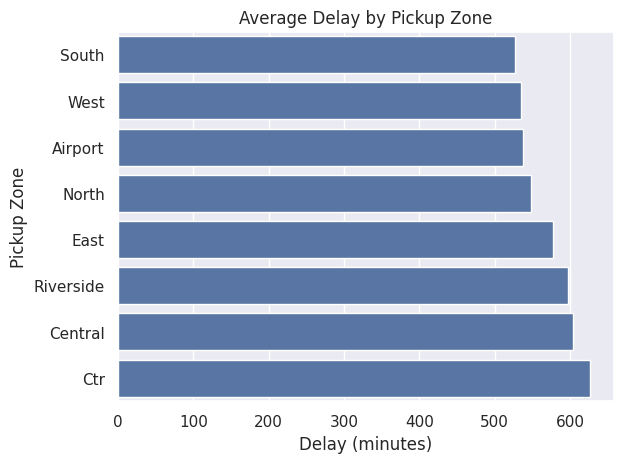

In [124]:
avg_delay_zone = master_df.groupby("pickup_zone")["delay_minutes"].mean().sort_values()

sns.barplot(x=avg_delay_zone.values, y=avg_delay_zone.index)
plt.title("Average Delay by Pickup Zone")
plt.xlabel("Delay (minutes)")
plt.ylabel("Pickup Zone")
plt.show()

2. Average delay by Hub

This chart compares average delays across hubs to identify which hubs are contributing most to delivery inefficiences.

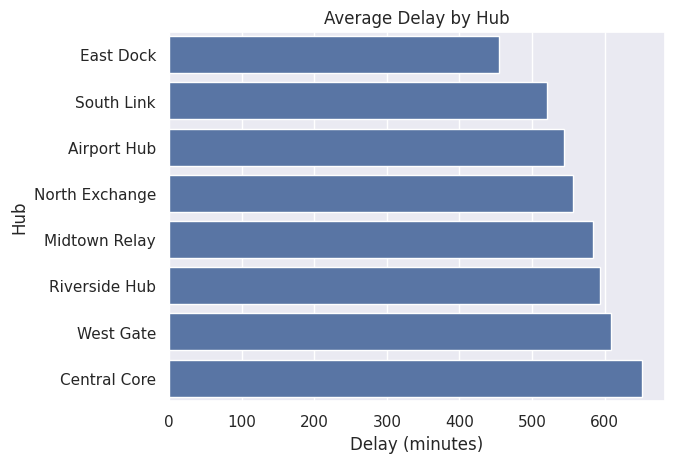

In [125]:
avg_delay_hub = master_df.groupby("hub_name")["delay_minutes"].mean().sort_values()

sns.barplot(x=avg_delay_hub.values, y=avg_delay_hub.index)
plt.title("Average Delay by Hub")
plt.xlabel("Delay (minutes)")
plt.ylabel("Hub")
plt.show()

3. Worst drivers

This chart highlights the top 10 drivers with the highest average delays, indicating potential performance issues.

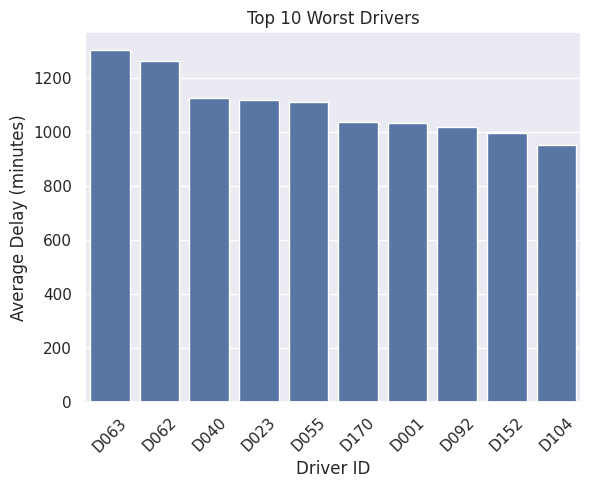

In [126]:
worst_drivers = master_df.groupby("driver_id")["delay_minutes"].mean().sort_values(ascending=False).head(10)

sns.barplot(x=worst_drivers.index, y=worst_drivers.values)
plt.title("Top 10 Worst Drivers")
plt.xlabel("Driver ID")
plt.ylabel("Average Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

4. Worst Hubs by risk score

This chart shows hubs ranked by overall risk, combining delays, complaints and incidents into a single performance metric.

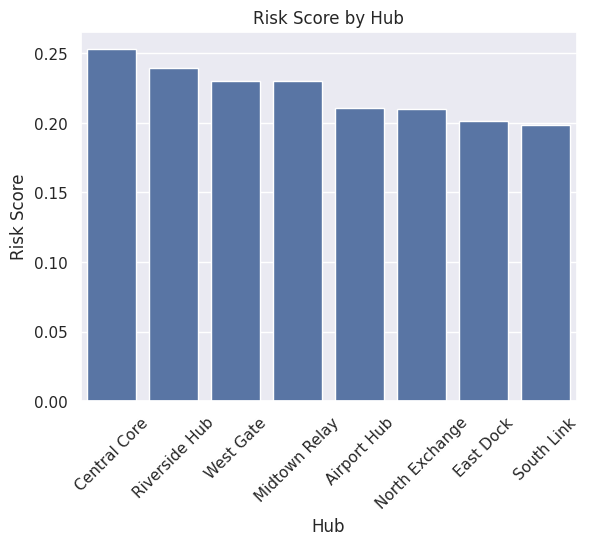

In [128]:
master_df["risk_score"] = (
    (master_df["delay_minutes"] / master_df["delay_minutes"].max()) * 0.7
    + (master_df["has_complaint"] * 0.2)
    + (master_df["has_incident"] * 0.1)
)


risk_hubs = master_df.groupby("hub_name")["risk_score"].mean().sort_values(ascending=False)

sns.barplot(x=risk_hubs.index, y=risk_hubs.values)
plt.title("Risk Score by Hub")
plt.xlabel("Hub")
plt.ylabel("Risk Score")
plt.xticks(rotation=45)
plt.show()

5. Complaints by pickup zone

This chart displays the number of complaints im each pickup zone, helping identify areas with poor customer experience.

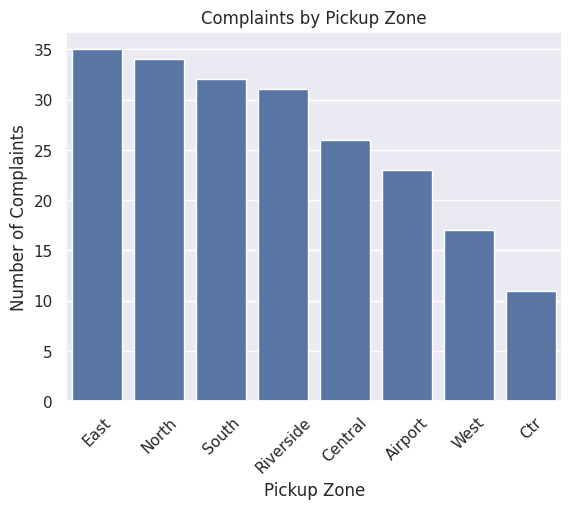

In [129]:
complaints_zone = master_df.groupby("pickup_zone")["has_complaint"].sum().sort_values(ascending=False)

sns.barplot(x=complaints_zone.index, y=complaints_zone.values)
plt.title("Complaints by Pickup Zone")
plt.xlabel("Pickup Zone")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.show()

6. Incidents count

This chart counts incidents per hub.

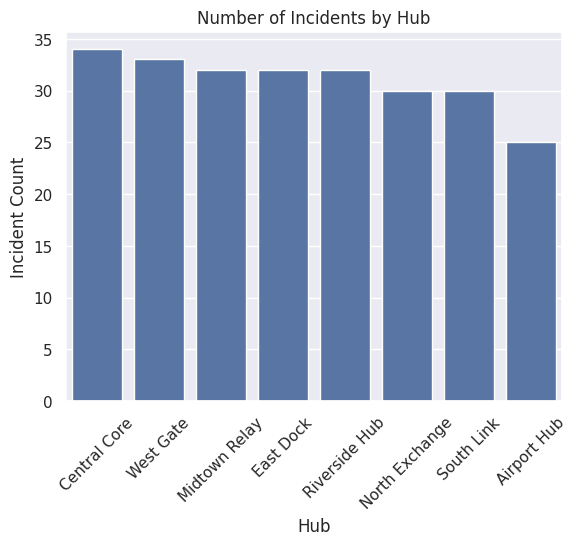

In [133]:
incident_counts = master_df.groupby("hub_name")["has_incident"].sum().sort_values(ascending=False)
sns.barplot(x=incident_counts.index, y=incident_counts.values)
plt.title("Number of Incidents by Hub")
plt.xlabel("Hub")
plt.ylabel("Incident Count")
plt.xticks(rotation=45)
plt.show()

7. App events per day

This chart illustrates how app usage changes over time, revealing patterns in user activity and demand.

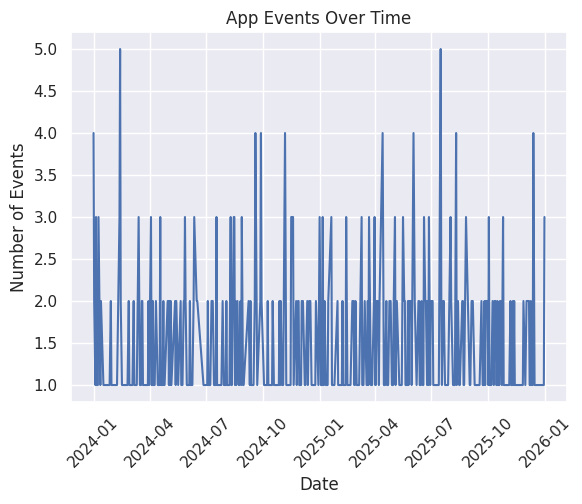

In [131]:
events_per_day = app_events.groupby(app_events["event_timestamp"].dt.date)["event_id"].count()

sns.lineplot(x=events_per_day.index, y=events_per_day.values)
plt.title("App Events Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.show()

EXPORT CLEANED DATASET

In [134]:
master_df.to_csv("cleaned_data.csv", index=False)

In [135]:
from google.colab import files
files.download("cleaned_data.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>